# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


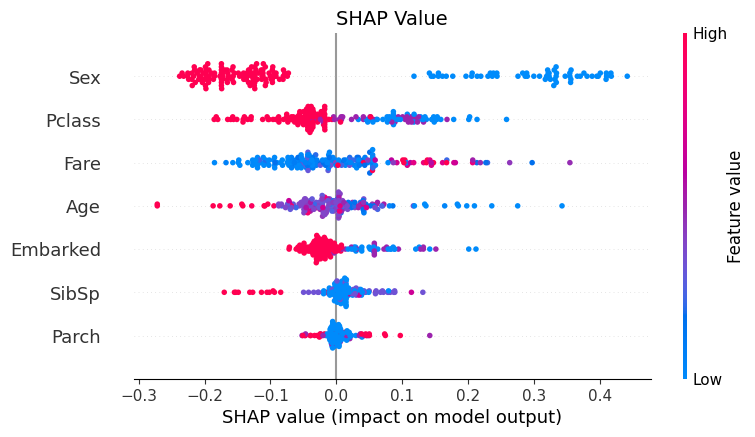

Stacking F1: 0.765625


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거,
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
#  데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 전처리
# 분석에 도움이 되지 않는 고객 id 제거
df = df.drop(columns=['customer_id'], errors='ignore')


# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

# 범주형 칼럼인 국가와 성별을 인코딩, 
df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

encoders = {'country': le_country, 'gender': le_gender}

for col_name, encoder in encoders.items():
    mapping = {i: class_name for i, class_name in enumerate(encoder.classes_)}
    print(f"[{col_name}] 매핑 정보: {mapping}")
# 추후 shap value 분석을 위해 매핑정보 확인.


[country] 매핑 정보: {0: 'France', 1: 'Germany', 2: 'Spain'}
[gender] 매핑 정보: {0: 'Female', 1: 'Male'}


In [2]:
# split - train, valid 8:2로 분리
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42)

from pycaret.classification import *

# PyCaret 설정, target은 이탈여부.
clf = setup(
              data          = train_df, 
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8641,0.8583,0.4839,0.7701,0.5934,0.5170,0.5376,0.9550
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.0930
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.0940
xgboost,Extreme Gradient Boosting,0.8507,0.8346,0.4996,0.6895,0.5787,0.4909,0.5007,0.0260
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0370
rf,Random Forest Classifier,0.8580,0.8393,0.4588,0.7541,0.5691,0.4904,0.5128,0.0950
et,Extra Trees Classifier,0.8507,0.8344,0.4344,0.7291,0.5441,0.4618,0.4840,0.0670
dt,Decision Tree Classifier,0.7868,0.6865,0.5161,0.4829,0.4986,0.3635,0.3640,0.0090
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0100
lda,Linear Discriminant Analysis,0.8021,0.7562,0.1946,0.5571,0.2877,0.2026,0.2410,0.0080


* 분석에 필요없는 고객id 칼럼을 제거하고, 범주형 칼럼인 성별과 국가를 인코딩한다.
* 데이터 전처리 후 train, valid 데이터를 8:2로 분리한다.
* automl을 통해 분류 모델들을 불러와 f1을 기준으로 모델 성능을 비교한다. 
* 본 데이터 기준, 성능 top 4 모델은 catboost, lightgbm, gbc, xgboost이다. 따라서 하이퍼파라미터 튜닝 및 스태킹 모델링을 이 4가지 모델로 진행한다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


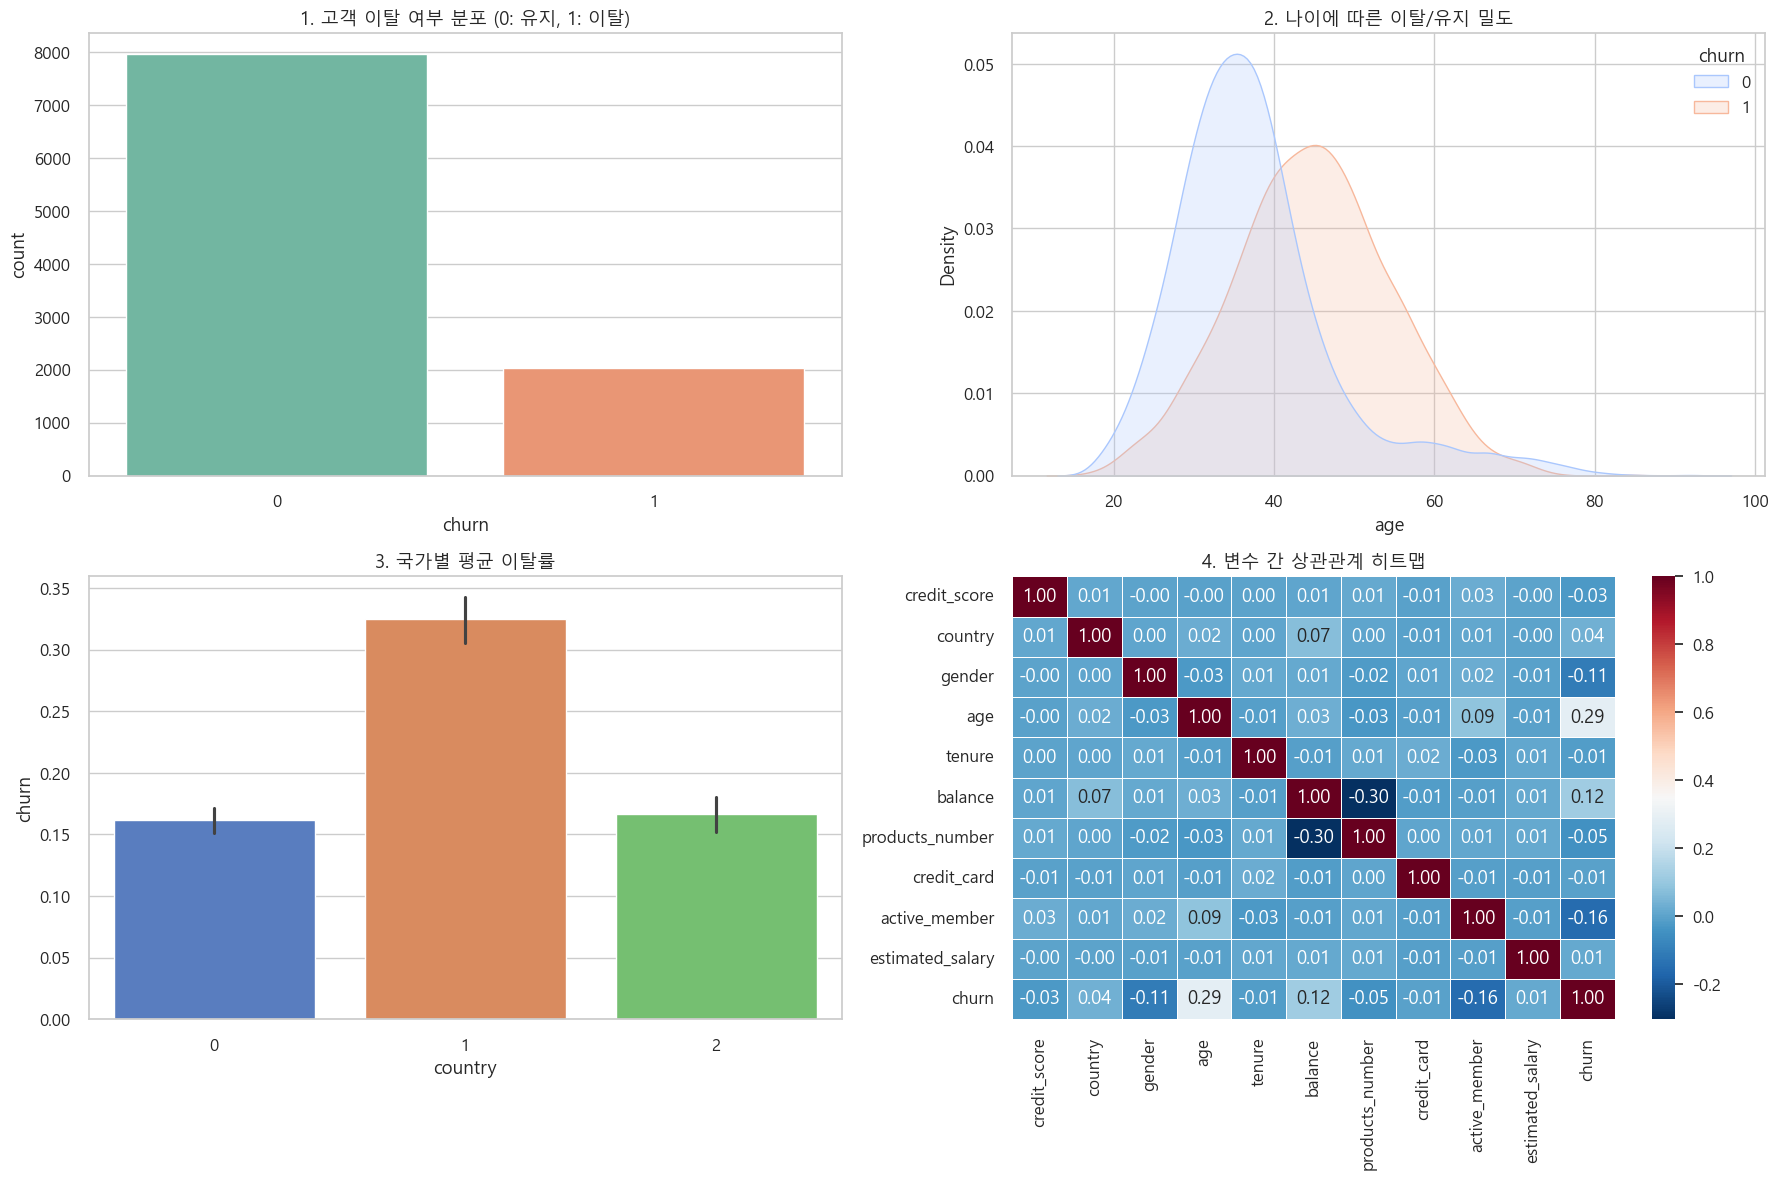

In [3]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
df.info()
# info를 통해 결측치 확인. 

df = df.drop(columns=['customer_id'], errors='ignore')
# 분석에 필요없는 칼럼(customer_id) 삭제

# 범주형 인코딩 - 성별, 국가 칼럼
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn 테마 설정 후 폰트 설정
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(18, 12))

# y(이탈 여부) 분포 - 클래스 비율 확인을 위해
plt.subplot(2, 2, 1)
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('1. 고객 이탈 여부 분포 (0: 유지, 1: 이탈)')

# 나이에 따른 이탈 밀도 - 가장 이탈이 많이 일어나는 연령대를 확인
plt.subplot(2, 2, 2)
sns.kdeplot(x='age', hue='churn', data=df, fill=True, common_norm=False, palette='coolwarm')
plt.title('2. 나이에 따른 이탈/유지 밀도')

# 국가별 이탈율 - 가장 이탈이 많이 일어나는 국가 확인
plt.subplot(2, 2, 3)
sns.barplot(x='country', y='churn', data=df, palette='muted')
plt.title('3. 국가별 평균 이탈률')
# 인코딩된 숫자를 실제 이름으로 보려면 매핑 정보 참고

# 전체 상관관계 히트맵 - 칼럼 별 상관관계를 확인
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('4. 변수 간 상관관계 히트맵')

plt.tight_layout()
plt.show()

1. y(이탈 여부)의 비율 확인 결과, 이탈 고객에 비해 유지 고객의 비율이 훨씬 높다 -> 클래스 불균형
2. 나이에 따른 이탈여부를 kde그래프로 확인 결과, 유지고객은 30대가 가장 높고, 이탈고객은 40대가 가장 많았다.
3. 국가별 이탈률 확인 결과, 1위: 독일 / 2위: 스페인 / 3위: 프랑스 순으로 나왔다.
4. 변수 간 상관관계를 히트맵으로 확인한 결과, 큰 상관관계를 보이는 변수의 조합은 발견되지 않았고, 그나마 상품의 수와 계좌 잔액이 -0.30으로 음의 상관관계를 보이고 있다.

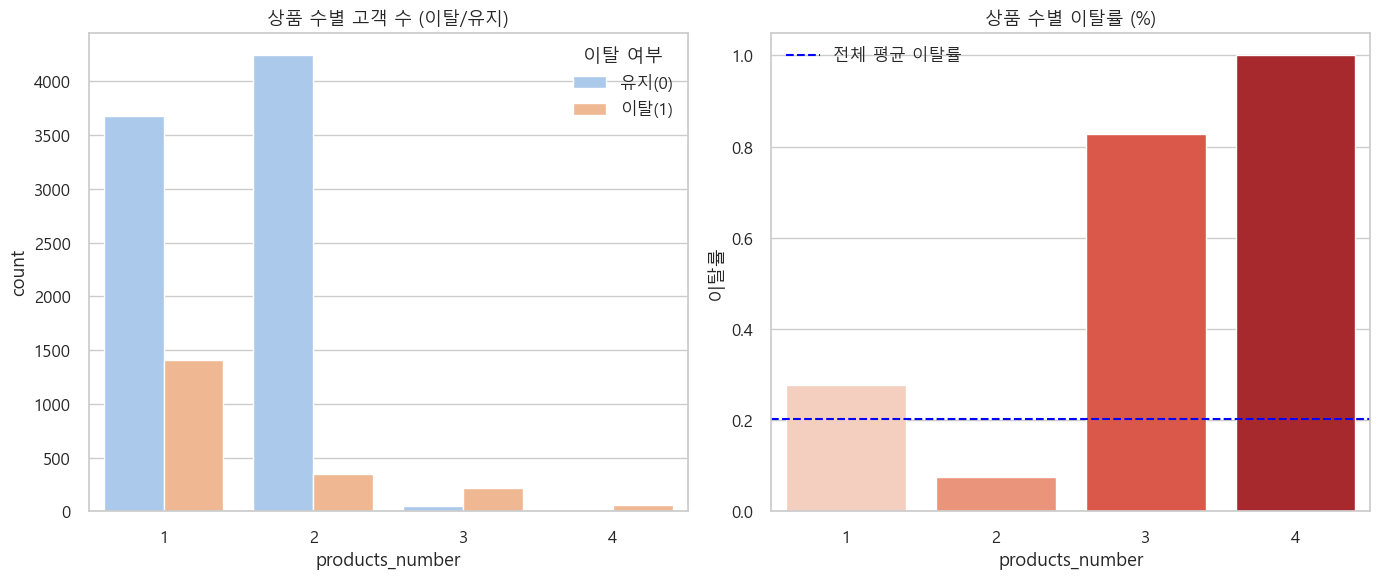

In [ ]:
# 상품 수로 groupby 후 평균을 구해 이탈여부칼럼만 불러온다.
churn_rate_by_product = df.groupby('products_number')['churn'].mean().reset_index()

plt.figure(figsize=(14, 6))

# [왼쪽] 상품 수별 고객 수 확인 
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='products_number', hue='churn', palette='pastel')
plt.title('상품 수별 고객 수 (이탈/유지)', fontsize=13)
plt.legend(title='이탈 여부', labels=['유지(0)', '이탈(1)'])

# [오른쪽] 상품 수별 이탈률 확인
plt.subplot(1, 2, 2)
sns.barplot(data=churn_rate_by_product, x='products_number', y='churn', palette='Reds')
plt.axhline(df['churn'].mean(), color='blue', linestyle='--', label='전체 평균 이탈률') # 전체 평균선
plt.title('상품 수별 이탈률 (%)', fontsize=13)
plt.ylabel('이탈률')
plt.legend()

plt.tight_layout()
plt.show()

클래스 불균형이 보여 상품 수 별 고객 수와 이탈률을 시각화한 결과, 상품 보유량이 많은 고객들의 이탈률이 높은 건 맞지만, 이탈 고객의 데이터가 훨씬 작아 이를 해결하여 자세한 분석이 필요해보인다.

In [ ]:
# X, y 변수 지정
X = df.drop('churn', axis=1)
y = df['churn']

# train valid split, 8:2로 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


from sklearn.preprocessing import StandardScaler
# 스케일링, X_train 스케일링 후, 거기에 기반해 X_valid 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


In [ ]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import optuna
from sklearn.metrics import f1_score

# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

# 위 automl을 이용해 상위 성능 4개의 모델을 선정 - catboost, lightgbm, gbc, xgboost
# 선정한 각 모델의 하이퍼파라미터 범위 지정 후 optuna를 이용해 하이퍼파라미터 튜닝 진행
def objective_CB(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10)
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_LGBM(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
    }
    model = LGBMClassifier(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_GB(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_XGB(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

import optuna
# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색, 각 모델 당 n_trials만큼 반복 탐색
study_CB = optuna.create_study(direction='maximize')
study_CB.optimize(objective_CB, n_trials=10)

study_LGBM = optuna.create_study(direction='maximize')
study_LGBM.optimize(objective_LGBM, n_trials=10)

study_GB = optuna.create_study(direction='maximize')
study_GB.optimize(objective_GB, n_trials=10)

study_XGB = optuna.create_study(direction='maximize')
study_XGB.optimize(objective_XGB, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
CB = CatBoostClassifier(**study_CB.best_params)
LGBM = LGBMClassifier(**study_LGBM.best_params)
GB = GradientBoostingClassifier(**study_GB.best_params)
XGB = XGBClassifier(**study_XGB.best_params)

[I 2026-04-09 14:59:08,144] A new study created in memory with name: no-name-c42aacba-5240-4017-a49b-10e7a2f1f825
[I 2026-04-09 14:59:08,303] Trial 0 finished with value: 0.5654952076677316 and parameters: {'iterations': 102, 'depth': 4, 'learning_rate': 0.05142009215002888, 'l2_leaf_reg': 8.596337926117592}. Best is trial 0 with value: 0.5654952076677316.


0:	learn: 0.6704077	total: 1.57ms	remaining: 158ms
1:	learn: 0.6466274	total: 2.89ms	remaining: 144ms
2:	learn: 0.6251691	total: 3.84ms	remaining: 127ms
3:	learn: 0.6065555	total: 4.78ms	remaining: 117ms
4:	learn: 0.5888080	total: 5.63ms	remaining: 109ms
5:	learn: 0.5722352	total: 6.71ms	remaining: 107ms
6:	learn: 0.5571895	total: 8.09ms	remaining: 110ms
7:	learn: 0.5437534	total: 9.2ms	remaining: 108ms
8:	learn: 0.5309158	total: 10.4ms	remaining: 107ms
9:	learn: 0.5201092	total: 11.5ms	remaining: 106ms
10:	learn: 0.5096220	total: 12.4ms	remaining: 103ms
11:	learn: 0.4996324	total: 13.5ms	remaining: 101ms
12:	learn: 0.4907729	total: 14.4ms	remaining: 98.8ms
13:	learn: 0.4820081	total: 15.3ms	remaining: 96.2ms
14:	learn: 0.4743874	total: 16.1ms	remaining: 93.5ms
15:	learn: 0.4677248	total: 17.1ms	remaining: 91.7ms
16:	learn: 0.4605220	total: 18.3ms	remaining: 91.5ms
17:	learn: 0.4545120	total: 19.3ms	remaining: 90ms
18:	learn: 0.4494095	total: 20.2ms	remaining: 88.2ms
19:	learn: 0.44359

[I 2026-04-09 14:59:09,750] Trial 1 finished with value: 0.593939393939394 and parameters: {'iterations': 422, 'depth': 7, 'learning_rate': 0.06891056833616406, 'l2_leaf_reg': 6.603847312271423}. Best is trial 1 with value: 0.593939393939394.


377:	learn: 0.2099577	total: 1.22s	remaining: 142ms
378:	learn: 0.2098495	total: 1.22s	remaining: 139ms
379:	learn: 0.2096122	total: 1.23s	remaining: 135ms
380:	learn: 0.2094402	total: 1.23s	remaining: 132ms
381:	learn: 0.2092194	total: 1.23s	remaining: 129ms
382:	learn: 0.2090186	total: 1.24s	remaining: 126ms
383:	learn: 0.2087503	total: 1.24s	remaining: 123ms
384:	learn: 0.2085509	total: 1.24s	remaining: 119ms
385:	learn: 0.2083529	total: 1.25s	remaining: 116ms
386:	learn: 0.2081081	total: 1.25s	remaining: 113ms
387:	learn: 0.2078860	total: 1.25s	remaining: 110ms
388:	learn: 0.2074260	total: 1.26s	remaining: 107ms
389:	learn: 0.2071841	total: 1.26s	remaining: 103ms
390:	learn: 0.2070706	total: 1.26s	remaining: 100ms
391:	learn: 0.2067452	total: 1.27s	remaining: 96.9ms
392:	learn: 0.2064530	total: 1.27s	remaining: 93.7ms
393:	learn: 0.2062979	total: 1.27s	remaining: 90.5ms
394:	learn: 0.2061006	total: 1.28s	remaining: 87.3ms
395:	learn: 0.2059204	total: 1.28s	remaining: 84.1ms
396:	le

[I 2026-04-09 14:59:11,339] Trial 2 finished with value: 0.603030303030303 and parameters: {'iterations': 349, 'depth': 8, 'learning_rate': 0.059144085742939924, 'l2_leaf_reg': 6.48434045673399}. Best is trial 2 with value: 0.603030303030303.


...

[I 2026-04-09 14:59:22,591] Trial 7 finished with value: 0.575 and parameters: {'n_estimators': 153, 'max_depth': 4, 'learning_rate': 0.013992290850974379, 'num_leaves': 137, 'min_child_samples': 12}. Best is trial 1 with value: 0.5813253012048193.


[LightGBM] [Warning] num_iterations is set=1000, max_iter=1000 will be ignored. Current value: num_iterations=1000
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

[I 2026-04-09 14:59:23,137] Trial 8 finished with value: 0.5916795069337443 and parameters: {'n_estimators': 430, 'max_depth': 4, 'learning_rate': 0.017940847512541165, 'num_leaves': 130, 'min_child_samples': 32}. Best is trial 8 with value: 0.5916795069337443.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-09 14:59:24,367] Trial 9 finished with value: 0.5472496473906912 and parameters: {'n_estimators': 275, 'max_depth': 8, 'learning_rate': 0.09550919221381514, 'num_leaves': 66, 'min_child_samples': 30}. Best is trial 8 with value: 0.5916795069337443.
[I 2026-04-09 14:59:24,369] A new study created in memory with name: no-name-e54df468-1301-45b7-b791-dd308a869790
[I 2026-04-09 14:59:28,137] Trial 0 finished with value: 0.5864661654135338 and parameters: {'n_estimators': 274, 'learning_rate': 0.03631063853042175, 'max_depth': 6, 'subsample': 0.7608795313974877}. Best is trial 0 with value: 0.5864661654135338.
[I 2026-04-09 14:59:30,087] Trial 1 finished with value: 0.6102719033232629 and parameters: {'n_estimators': 271, 'learning_rate': 0.06174905990658595, 'max_depth': 3, 'subsample': 0.8039652515453608}. Best is trial 1 with value: 0.6102719033232629.
[I 2026-04-09 14:59:32,134] Trial 2 finished with value: 0.6080246913580247 and parameters: {'n_estimators': 217, 'learning_ra

* 위에서 선정한 상위 4개의 모델들을 대상으로 optuna를 이용해 하이퍼파라미터튜닝을 진행한다.
* 각 모델에 들어가는 하이퍼파라미터들 중 몇 가지를 선택하여 범위를 설정한다.
* 각 모델 마다 n_trials에 지정한 수 만큼 반복하여 최적의 하이퍼파라미터를 찾는다.
* optuna로 찾은 최적의 옵션을 각 변수에 저장한다.

In [ ]:
# 모델 학습
CB.fit(X_train, y_train)
LGBM.fit(X_train, y_train)
GB.fit(X_train, y_train)
XGB.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
# 4가지 모델 각각 X_valid를 이용한 예측 값과 y_valid 데이터를 이용해 f1_score출력
for name, model in [('CB', CB), ('LGBM', LGBM), ('GB', GB), ('XGB', XGB)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

0:	learn: 0.6467631	total: 2.03ms	remaining: 965ms
1:	learn: 0.5981251	total: 3.93ms	remaining: 931ms
2:	learn: 0.5653792	total: 5.39ms	remaining: 851ms
3:	learn: 0.5300397	total: 6.89ms	remaining: 813ms
4:	learn: 0.5067126	total: 8.39ms	remaining: 790ms
5:	learn: 0.4861749	total: 10.1ms	remaining: 792ms
6:	learn: 0.4656639	total: 12.2ms	remaining: 815ms
7:	learn: 0.4489859	total: 13.8ms	remaining: 808ms
8:	learn: 0.4357491	total: 15.4ms	remaining: 800ms
9:	learn: 0.4230121	total: 17.3ms	remaining: 806ms
10:	learn: 0.4151008	total: 19.1ms	remaining: 807ms
11:	learn: 0.4100431	total: 20.8ms	remaining: 806ms
12:	learn: 0.4034084	total: 22.5ms	remaining: 801ms
13:	learn: 0.3971840	total: 24.1ms	remaining: 794ms
14:	learn: 0.3922472	total: 26ms	remaining: 798ms
15:	learn: 0.3867596	total: 28.3ms	remaining: 814ms
16:	learn: 0.3829998	total: 30.1ms	remaining: 813ms
17:	learn: 0.3795252	total: 31.9ms	remaining: 811ms
18:	learn: 0.3770066	total: 33.8ms	remaining: 814ms
19:	learn: 0.3742371	tot

* 앞선 과정으로 찾은 성능 상위 4개의 모델과 각 모델의 최적의 하이퍼파라미터를 바탕으로 모델을 학습한다.
* 그 후 X_valid를 이용한 예측값과 y_valid데이터를 통해 각 모델의 f1_score를 출력한다.
* 위 4 모델 중 CatBoostClassifier모델이 가장 높은 성능을 보이고 있다.

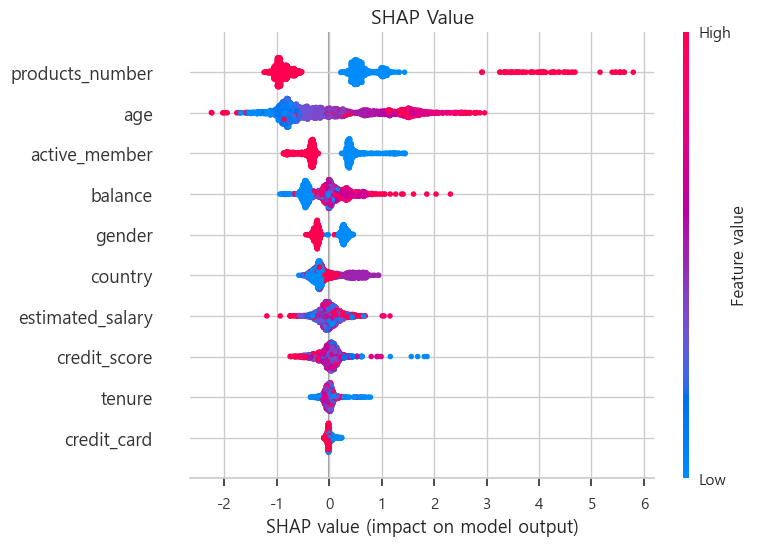

In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
import shap

# SHAP value - 가장 성능이 좋았던 catboost 선택
explainer = shap.TreeExplainer(CB)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()

# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1_score, Accuracy_score 출력

1. products_number: 보유 중인 상품 수가 너무 많으면 이탈위험이 있다. 1~2개 정도 적당히 보유한 고객들이 유지 될 확률이 높다.
2. age: 나이가 많을 수록 이탈 확률이 매우 높아지고, 젊은 세대는 상대적으로 이탈 확률이 낮다. 고령층 고객을 대상으로하는 프로모션 및 서비스가 필요해보인다.
3. active_member: 활성 고객과 비활성 고객은 명확하게 갈라져있다. 활동이 없는 고객은 이탈할 가능성이 매우 높다. 비활성 고객이 되기전에 예측하여 여러 프로모션을 통해 고객유치전략을 세워야한다.
4. balance: 잔고가 높을 수록 이탈률이 높은 경향이 있다. 우량 고객을 잡기 위한 전략이 필요하다.
5. gender: 두 성별이 나누어져있지만, 0부근에 다 모여있어 성별은 이탈을 결정짓는 요소는 아니다.
6. country: 앞선 시각화로 확인한 결과와 비슷하게 독일이 가장 우측에 분포되어있다.
7. estimated_salary: 0부근에 밀집되어있어 이탈을 결정짓는 요소는 아니다.
8. credit_score, tenure, credit: 모두 0부근에 밀집되어있어, 일탈을 결정짓는 요소는 아니다.

* 인사이트 제안
* 현재 다양한 칼럼을 분석한 결과, 여러 부분에서 고객 이탈이 일어나고 있다. 새로운 고객을 유치시키는 것보다 기존 고객을 유지하는 것이 리스크가 더 적고, 비용도 더 적게 들기 때문에 기존 고객을 유지시킬 전략을 세워야 한다.

1. 상품 다량 보유 고객 이탈 - 보유 상품의 수가 1개나 4개나 혜택의 차이가 크지 않을 수 있다. 상품의 수에 비례한 누적형 혜택 설계가 필요하다. 
2. 고령층 고객 이탈 - 디지털 기술이 불편한 고령층을 대상으로한 편의 서비스가 필요하다.
3. 비활성 고객 이탈 - 단순히 활성, 비활성으로 나누는 것이 아닌 비활성 위험 고객을 사전에 확인하여 여러 프로모션을 통해 계속해서 이용률을 유지시켜야 한다.
4. 우량 고객 이탈 - 고액 잔액 고객을 대상으로 고객전담서비스를 통해 이탈을 막아야한다. 

In [ ]:
from sklearn.ensemble import StackingClassifier

# 전방 모델 리스트
# 전방 모델에 상위 4개의 모델중 3개를 세팅한다.
est_model_list = [
                      ('XGB', XGB),
                      ('LGBM', LGBM),
                      ('GB', GB)
                  ]


# Stacking 모델 합체
# 후방 모델에는 가장 성능이 좋았던 CatBoost 모델을 세팅한다.
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = CatBoostClassifier() # 후방모델
)

# X_train, y_train을 이용해 모델 피팅
stack.fit(X_train, y_train)

# X_valid를 이용해 예측 값 출력
pred = stack.predict(X_valid)
# 예측 값과, y_valid를 이용해 f1_score 출력
print("Stacking F1:", f1_score(y_valid, pred))

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

* 위 과정을 통해 선정한 4개의 모델과 최적의 하이퍼파라미터를 통해 스태킹 모델링을 진행한다.
* 후방 모델에 가장 성능이 좋았던 CatBoost를 넣고, 나머지 3가지 모델을 전방 모델에 넣는다.
* X_train, y_train을 이용해 모델 피팅 후, X_valid를 이용해 예측 값 출력한다.
* 최종적으로 예측 값과 y_valid를 비교하여 f1_score를 출력한다.